<a href="https://colab.research.google.com/github/soumensen411/Food-Delivery-Time-Prediction-With-Machine-Learning/blob/main/Food_delivery_time_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML projects/Food Delivery Time Prediction/Food delivery.csv')

In [3]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [5]:
df.shape

(45593, 20)

In [6]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
del_colList = ['ID','Delivery_person_ID','Delivery_person_Age','']

In [9]:
df['Weatherconditions'].value_counts()

,count
Weatherconditions,
conditions Fog,7654
conditions Stormy,7586
conditions Cloudy,7536
conditions Sandstorms,7495
conditions Windy,7422
conditions Sunny,7284
conditions NaN,616


In [10]:
df[df['Weatherconditions'] == 'conditions NaN']

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
74,0xa9f,BANGRES13DEL01,NaN,NaN,12.935662,77.614130,12.975662,77.654130,11-03-2022,NaN,15:30:00,conditions NaN,NaN,1,Drinks,scooter,0,No,Metropolitian,(min) 19
120,0x6e2,VADRES06DEL01,NaN,NaN,22.312790,73.170283,22.422790,73.280283,02-04-2022,NaN,18:25:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25
250,0x1b50,PUNERES16DEL01,NaN,NaN,18.536718,73.830327,18.646718,73.940327,08-03-2022,NaN,21:25:00,conditions NaN,NaN,3,Buffet,motorcycle,1,Yes,Urban,(min) 43
348,0x4c1,BANGRES13DEL02,NaN,NaN,12.935662,77.614130,13.065662,77.744130,02-03-2022,NaN,00:05:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 26
425,0xc003,DEHRES13DEL02,NaN,NaN,-30.366322,-78.070453,30.496322,78.200453,18-02-2022,NaN,22:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45332,0x2950,VADRES04DEL02,50,6,0.000000,0.000000,0.020000,0.020000,19-03-2022,NaN,10:40:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Urban,(min) 28
45394,0xdc4,RANCHIRES02DEL03,NaN,NaN,0.000000,0.000000,0.030000,0.030000,05-03-2022,NaN,17:25:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 21
45504,0x461,BANGRES07DEL02,NaN,NaN,-12.978453,-77.643685,12.998453,77.663685,17-03-2022,NaN,09:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,NaN,(min) 24
45518,0x863,INDORES05DEL01,NaN,NaN,22.727021,75.884167,22.737021,75.894167,19-03-2022,NaN,11:40:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25


In [11]:
df['Weatherconditions'] = df['Weatherconditions'].str.removeprefix('conditions ')

In [12]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [13]:
cat_col = df.select_dtypes(include='object').columns
cat_col

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='object')

In [14]:
for col in cat_col:
  df[col] = df[col].str.strip()
  df[col] = df[col].replace("NaN",np.nan)

In [15]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [16]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.removeprefix('(min)')
df['Time_taken(min)'] =  df['Time_taken(min)'].astype(int)

In [17]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
  df[col] = pd.to_numeric(df[col],errors='coerce')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [19]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.633780,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.334716,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [20]:
# rating greater than 5
df[df['Delivery_person_Ratings']>5]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
3586,0x46d,BANGRES05DEL01,50.0,6.0,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,NaN,NaN,3,Meal,electric_scooter,0.0,No,Urban,25
4714,0x493,HYDRES17DEL01,50.0,6.0,-17.451976,-78.385883,17.561976,78.495883,04-04-2022,NaN,23:20:00,NaN,NaN,3,Snack,bicycle,0.0,No,Metropolitian,27
5169,0x4f2,JAPRES08DEL01,50.0,6.0,-26.910262,-75.783013,27.020262,75.893013,18-03-2022,NaN,18:50:00,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,20
5362,0x430,BANGRES19DEL01,50.0,6.0,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:55:00,NaN,NaN,3,Meal,electric_scooter,1.0,No,Metropolitian,18
5651,0xbef1,AGRRES13DEL02,50.0,6.0,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:00,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,20
6394,0x427,JAPRES06DEL02,50.0,6.0,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:10:00,NaN,NaN,3,Meal,electric_scooter,0.0,No,Urban,20
7031,0x3eb,MYSRES15DEL02,50.0,6.0,-12.352058,-76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:00,NaN,NaN,3,Buffet,scooter,1.0,No,Metropolitian,14
7681,0xd42,VADRES09DEL01,50.0,6.0,0.000000,0.000000,0.010000,0.010000,21-03-2022,NaN,08:35:00,NaN,NaN,3,Meal,bicycle,1.0,No,Metropolitian,22
9499,0x3f0,BANGRES010DEL01,50.0,6.0,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:25:00,NaN,NaN,3,Drinks,scooter,1.0,No,Urban,17
9535,0x3ef,RANCHIRES13DEL01,50.0,6.0,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,17:55:00,NaN,NaN,3,Snack,bicycle,1.0,No,Metropolitian,32


In [21]:
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].clip(upper=5)

In [22]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
  df[col] = df[col].fillna(df[col].median())

In [23]:
for col in ['Weatherconditions','City','Road_traffic_density','Festival']:
  df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

# EDA

In [25]:
df['Time_taken(min)'].describe()

,Time_taken(min)
count,45593.000000
mean,26.294607
std,9.383806
min,10.000000
25%,19.000000
50%,26.000000
75%,32.000000
max,54.000000


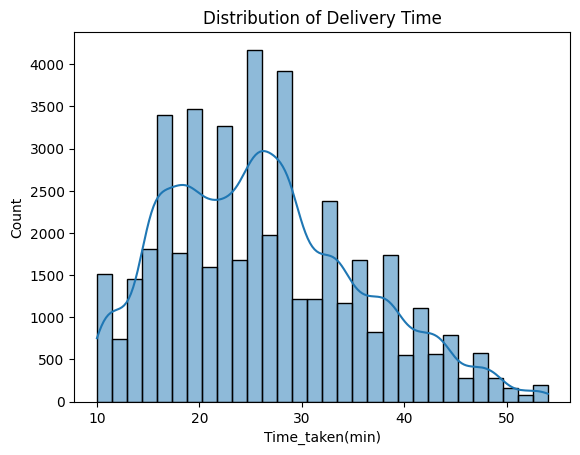

In [26]:
sns.histplot(df['Time_taken(min)'],bins=30,kde=True)
plt.title('Distribution of Delivery Time')
plt.show()

In [27]:
df.groupby('Road_traffic_density')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Road_traffic_density,,,,
High,4425,27.240000,27.0,8.396012
Jam,14143,31.176624,31.0,9.940904
Low,16078,21.464175,21.0,6.988438
Medium,10947,26.699644,27.0,8.560179


In [28]:
df.groupby('Weatherconditions')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Weatherconditions,,,,
Cloudy,7536,28.917330,28.0,10.084352
Fog,8270,28.739541,28.0,10.100816
Sandstorms,7495,25.875517,26.0,8.618434
Stormy,7586,25.870815,26.0,8.473273
Sunny,7284,21.856947,20.0,8.327210
Windy,7422,26.118836,26.0,8.615702


In [29]:
df.groupby('Festival')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Festival,,,,
No,44697,25.909256,25.0,9.052291
Yes,896,45.517857,45.0,4.001915


In [30]:
df.groupby('City')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
City,,,,
Metropolitian,35293,27.136486,26.0,9.205358
Semi-Urban,164,49.731707,49.0,2.693089
Urban,10136,22.984017,22.0,8.866011


In [31]:
df.groupby('Type_of_order')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Type_of_order,,,,
Buffet,11280,26.283511,26.0,9.411344
Drinks,11322,26.187953,25.0,9.298465
Meal,11458,26.419270,26.0,9.424849
Snack,11533,26.286309,26.0,9.399147


In [32]:
df.groupby('Type_of_vehicle')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Type_of_vehicle,,,,
bicycle,68,26.426471,26.0,9.262855
electric_scooter,3814,24.470110,24.0,8.610859
motorcycle,26435,27.605674,26.0,9.647811
scooter,15276,24.480754,24.0,8.704238


In [33]:
df['Delivery_person_Age'].describe()

,Delivery_person_Age
count,45593.000000
mean,29.584739
std,5.696333
min,15.000000
25%,25.000000
50%,30.000000
75%,34.000000
max,50.000000


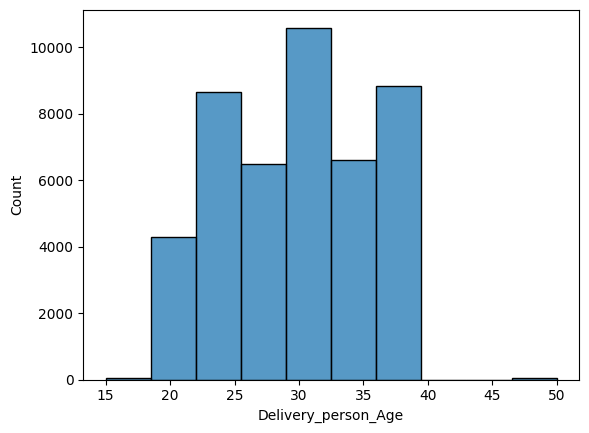

In [34]:
sns.histplot(df['Delivery_person_Age'],bins=10)
plt.show()

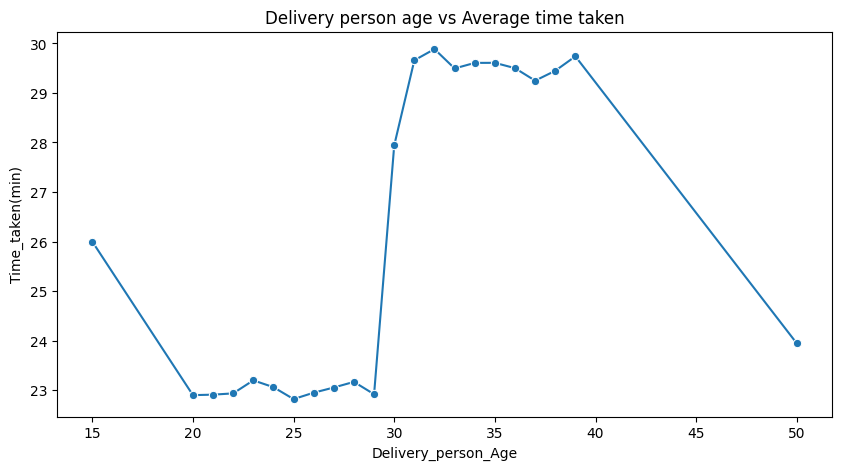

In [35]:
plt.figure(figsize=(10,5))
sns.lineplot(x=df['Delivery_person_Age'],y=df['Time_taken(min)'],estimator='mean',marker="o",errorbar=None)
plt.title('Delivery person age vs Average time taken')
plt.show()

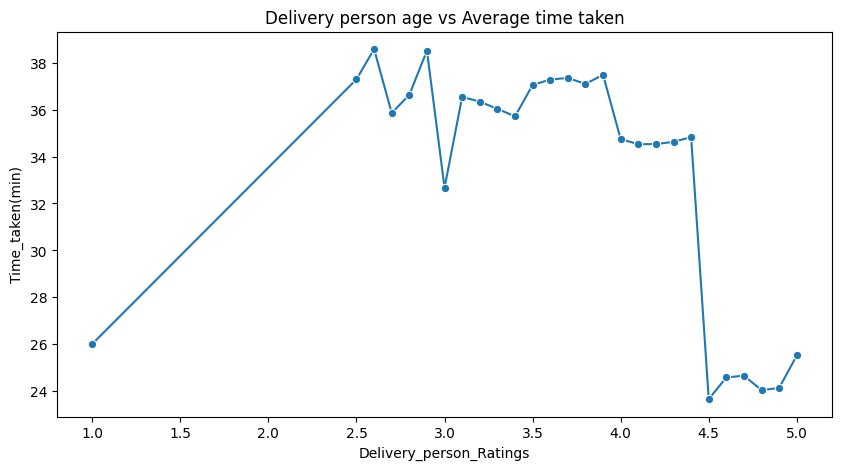

In [36]:
plt.figure(figsize=(10,5))
sns.lineplot(x=df['Delivery_person_Ratings'],y=df['Time_taken(min)'],estimator='mean',marker="o",errorbar=None)
plt.title('Delivery person age vs Average time taken')
plt.show()

<Axes: >

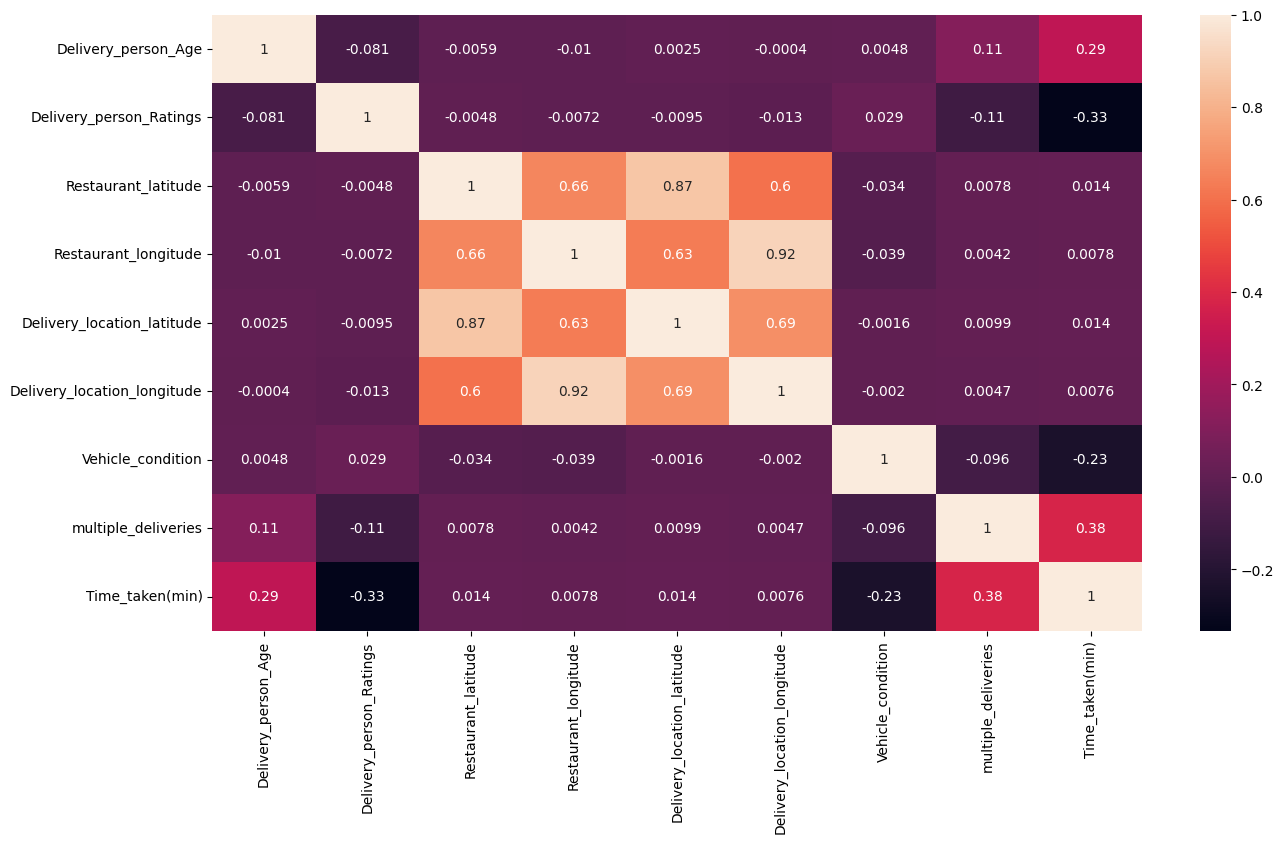

In [37]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Feature Engineering


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [39]:
df['Order_Date'][0]

'19-03-2022'

In [40]:
hour = pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S',errors='coerce').dt.hour

In [41]:
hour.unique()

array([11., 19.,  8., 18., 13., 21., 17., 20., 14.,  9., 22., 12., 23.,
       nan, 10., 16., 15.,  0.])

In [42]:
df.groupby(hour)['Time_taken(min)'].agg(['mean','median'])

,mean,median
Time_Orderd,,
0.0,22.169767,21.0
8.0,19.584158,19.0
9.0,19.543914,19.0
10.0,19.482170,19.0
11.0,26.380734,27.0
12.0,26.826233,27.0
13.0,27.538265,27.0
14.0,27.537295,27.0
15.0,23.194731,23.0


In [43]:
import math

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers

    # Convert degrees to radians
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = math.sin(dlat / 2)**2 + \
        math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2

    c = 2 * math.asin(math.sqrt(a))

    return R * c


In [44]:
df['Distance'] = df.apply(lambda row: haversine(row['Restaurant_latitude'], row['Restaurant_longitude'], row['Delivery_location_latitude'], row['Delivery_location_longitude']), axis=1)

In [45]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [47]:
df['Distance'].describe()

,Distance
count,45593.000000
mean,99.303911
std,1099.731281
min,1.465067
25%,4.663493
50%,9.264281
75%,13.763977
max,19692.674606


In [48]:
df[df['Distance']>100]['Distance'].describe()

,Distance
count,431.000000
mean,9484.671093
std,6252.618252
min,2216.065794
25%,4434.856783
50%,5897.015762
75%,17132.390571
max,19692.674606


In [49]:
df[df['Distance']<100]['Distance'].describe()

,Distance
count,45162.000000
mean,9.735396
std,5.608508
min,1.465067
25%,4.663412
50%,9.220209
75%,13.681490
max,20.969489


In [50]:
df[df['Distance']>100]['Distance'].describe()

,Distance
count,431.000000
mean,9484.671093
std,6252.618252
min,2216.065794
25%,4434.856783
50%,5897.015762
75%,17132.390571
max,19692.674606


In [51]:
df = df[df['Distance']<100].reset_index(drop=True)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45162 non-null  object 
 1   Delivery_person_ID           45162 non-null  object 
 2   Delivery_person_Age          45162 non-null  float64
 3   Delivery_person_Ratings      45162 non-null  float64
 4   Restaurant_latitude          45162 non-null  float64
 5   Restaurant_longitude         45162 non-null  float64
 6   Delivery_location_latitude   45162 non-null  float64
 7   Delivery_location_longitude  45162 non-null  float64
 8   Order_Date                   45162 non-null  object 
 9   Time_Orderd                  43706 non-null  object 
 10  Time_Order_picked            45162 non-null  object 
 11  Weatherconditions            45162 non-null  object 
 12  Road_traffic_density         45162 non-null  object 
 13  Vehicle_conditio

In [53]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138


In [54]:
df['Time_Orderd']

,Time_Orderd
0,11:30:00
1,19:45:00
2,08:30:00
3,18:00:00
4,13:30:00
...,...
45157,11:35:00
45158,19:55:00
45159,23:50:00
45160,13:35:00


In [55]:
from os import error
df['Order_hour'] = pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S',errors='coerce').dt.hour

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45162 non-null  object 
 1   Delivery_person_ID           45162 non-null  object 
 2   Delivery_person_Age          45162 non-null  float64
 3   Delivery_person_Ratings      45162 non-null  float64
 4   Restaurant_latitude          45162 non-null  float64
 5   Restaurant_longitude         45162 non-null  float64
 6   Delivery_location_latitude   45162 non-null  float64
 7   Delivery_location_longitude  45162 non-null  float64
 8   Order_Date                   45162 non-null  object 
 9   Time_Orderd                  43706 non-null  object 
 10  Time_Order_picked            45162 non-null  object 
 11  Weatherconditions            45162 non-null  object 
 12  Road_traffic_density         45162 non-null  object 
 13  Vehicle_conditio

In [57]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance,Order_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149,11.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530,19.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758,8.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401,18.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138,13.0


In [58]:
df['Order_hour'].isnull().sum()

np.int64(1456)

In [59]:
df['Order_hour']  = df['Order_hour'].fillna(df['Order_hour'].median())

# Assemble the feature matrix X and Target value Y


In [60]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'Distance', 'Order_hour'],
      dtype='object')

In [61]:
feature = ['Type_of_order','Delivery_person_Age','Delivery_person_Ratings','Distance','City','Order_hour','Weatherconditions','Road_traffic_density','Vehicle_condition','Type_of_vehicle','Festival','multiple_deliveries']

In [62]:
X = df[feature]

In [63]:
y = df['Time_taken(min)']

# Encoding categorical Values

In [64]:
df['Road_traffic_density'].unique()

array(['High', 'Jam', 'Low', 'Medium'], dtype=object)

In [65]:
traffic_mapping = {
    'Low':0,
    'Medium':1,
    'High':2,
    'Jam':3
}
X['Road_traffic_density'] = X['Road_traffic_density'].map(traffic_mapping)

/tmp/ipykernel_3967/357110016.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Road_traffic_density'] = X['Road_traffic_density'].map(traffic_mapping)


In [66]:
X['Road_traffic_density']

,Road_traffic_density
0,2
1,3
2,0
3,1
4,2
...,...
45157,2
45158,3
45159,0
45160,2


In [67]:
X = pd.get_dummies(X,columns = ['Type_of_vehicle','Weatherconditions','Festival','Type_of_order','City'],drop_first=True,dtype=int)

# Train_Test_Split

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model-1 Linear Regression (baseline)

In [72]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [73]:
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [74]:
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error

In [75]:
y_pred = lr.predict(X_test_scaled)

In [76]:
r2_test=r2_score(y_test,y_pred)

In [77]:
r2_test

0.569315466760959

In [83]:
mse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Linear Regression R-squared: {r2_test}")
print(f"Linear Regression Mean Squared Error: {mse_test}")

Linear Regression R-squared: 0.569315466760959
Linear Regression Mean Squared Error: 6.212510956097219


# Model-2 Random Forest

In [78]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

In [79]:
rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [80]:
y_pred_rf = rf.predict(X_test_scaled)

In [84]:
r2_test_rf = r2_score(y_test, y_pred_rf)
mse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest R-squared: {r2_test_rf}")
print(f"Random Forest Mean Squared Error: {mse_test_rf}")

Random Forest R-squared: 0.8189223768061562
Random Forest Mean Squared Error: 4.028282526452098


# Model-3 XGBoost

In [85]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)

In [86]:
xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [87]:
y_pred_xgb = xgb.predict(X_test_scaled)

In [88]:
r2_test_xgb = r2_score(y_test, y_pred_xgb)
mse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost R-squared: {r2_test_xgb}")
print(f"XGBoost Root Mean Squared Error: {mse_test_xgb}")

XGBoost R-squared: 0.8216072916984558
XGBoost Root Mean Squared Error: 3.9983063927130154


In [89]:
print(f"\n--- Model Performance Summary ---")
print(f"Linear Regression R-squared: {r2_test:.4f}")
print(f"Linear Regression RMSE: {mse_test:.4f}")
print(f"\nRandom Forest R-squared: {r2_test_rf:.4f}")
print(f"Random Forest RMSE: {mse_test_rf:.4f}")
print(f"\nXGBoost R-squared: {r2_test_xgb:.4f}")
print(f"XGBoost RMSE: {mse_test_xgb:.4f}")


--- Model Performance Summary ---
Linear Regression R-squared: 0.5693
Linear Regression RMSE: 6.2125

Random Forest R-squared: 0.8189
Random Forest RMSE: 4.0283

XGBoost R-squared: 0.8216
XGBoost RMSE: 3.9983
